# Análisis de Correspondencia

## Caso: Estudio de Detergentes

Se ha realizado un estudio de investigación de mercado con la finalidad de identificar características de los detergentes. Con esta finalidad se ha evaluado 5 marcas de detergentes respecto a 8 atributos considerados con mayor relevancia.

## Objetivo

Identificar la existencia de una relación entre las marcas de detergentes y sus atributos, así como la asociación de cada marca respecto a algunos atributos.

## ¿Qué es el Análisis de Correspondencia y para qué sirve?

El Análisis de Correspondencia (AC) es una técnica exploratoria multivariante, considerada dentro de los métodos de interdependencia, que se aplica especialmente a variables no métricas (variables cualitativas o categóricas). AC transforma una tabla de contingencia en una representación geométrica de baja dimensión de modo que filas y columnas con perfiles similares queden próximas en un mapa perceptual.

En este notebook aplicamos AC al estudio de detergentes: a partir de la tabla de contingencia entre marcas (columnas) y atributos (filas) calculamos los perfiles fila/columna, evaluamos la asociación global con la prueba chi-cuadrado y representamos gráficamente las coordenadas de filas y columnas para interpretar asociaciones y posicionamientos.

Puntos clave (contextualizados a este caso):

- AC es un método de interdependencia orientado a explorar relaciones entre categorías en una tabla de contingencia.
- Está pensado para variables cualitativas (no métricas); permite describir asociaciones entre marcas y atributos sin asumir medidas métricas previas.
- Establece relaciones entre variables categóricas observando frecuencias conjuntas y perfiles relativos.
- Analiza e interpreta la estructura interna de las relaciones entre atributos y marcas (por ejemplo, qué atributos se asocian a qué marcas).
- Describe dimensiones estructurales usando la métrica basada en la contribución del chi-cuadrado (las distancias en el espacio correspondiente se interpretan con la chi-cuadrado y no como métricas euclidianas simples).

## Consejos de Interpretación

- **Distancias en el mapa:** reflejan similitud de perfiles. Dos puntos cercanos tienen perfiles de respuestas parecidos.
- **Masa (proporciones marginales):** indica el peso relativo de una fila o columna en el análisis global.
- **Elipses y centroides:** resumen la dispersión de grupos y ayudan a visualizar áreas de asociación.
- **Porcentaje de inercia:** indica cuánta variabilidad de la tabla explica cada dimensión. Valores > 30% por dimensión son considerados buenos.
- **Contribuciones (CTR):** muestran cuánto aporta cada fila/columna a la formación de cada dimensión.

Sigue las celdas de cálculo para ver cómo se obtienen perfiles, la prueba estadística y las coordenadas usadas en las visualizaciones.

In [1]:
# ===========================================================
# IMPORTS
# ===========================================================
# Dependencias: numpy, pandas, scipy, prince, matplotlib, plotly
# Instalar si es necesario: pip install -r requirements.txt
# ===========================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import prince
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import plotly.graph_objects as go

---
## 1. Tabla de Contingencia

Construimos la tabla de frecuencias observadas: filas = atributos, columnas = marcas.

In [2]:
# Crear la tabla de contingencia
df = pd.DataFrame({
    'Brisa': [35, 10, 23, 2, 7, 32, 5, 9],
    'LimpiaMax': [13, 7, 18, 30, 8, 3, 24, 12],
    'EcoBrillo': [3, 30, 8, 3, 2, 1, 6, 9],
    'ProClean': [18, 15, 54, 20, 11, 19, 23, 23],
    'AquaFresh': [3, 15, 21, 2, 34, 0, 4, 5]
},
index=[
    'Publicidad TV',
    'Precio bajo',
    'Gama alta',
    'Alta eficacia',
    'Limpieza profunda',
    'Buena presentación',
    'Alto rendimiento',
    'Variedad de formatos'
])

print(f'Tabla de contingencia: {df.shape[0]} atributos x {df.shape[1]} marcas')
print(f'Total de observaciones: {df.values.sum()}')
print()
print(df)

Tabla de contingencia: 8 atributos x 5 marcas
Total de observaciones: 567

                      Brisa  LimpiaMax  EcoBrillo  ProClean  AquaFresh
Publicidad TV            35         13          3        18          3
Precio bajo              10          7         30        15         15
Gama alta                23         18          8        54         21
Alta eficacia             2         30          3        20          2
Limpieza profunda         7          8          2        11         34
Buena presentación       32          3          1        19          0
Alto rendimiento          5         24          6        23          4
Variedad de formatos      9         12          9        23          5


---
## 2. Perfiles de Fila

Cada fila se divide por su total para obtener la distribución relativa de cada atributo entre las marcas.

**Interpretación:** un valor de 0.4861 en "Publicidad TV" para Brisa significa que el 48.61% de las menciones de ese atributo corresponden a Brisa.

In [3]:
# =========================
# PERFILES FILA
# =========================

perfil_fila = df.div(df.sum(axis=1), axis=0)

# Agregar fila de masa (proporciones marginales de columnas)
masa_columnas = df.sum(axis=0) / df.values.sum()
perfil_fila.loc["Masa"] = masa_columnas

print("PERFILES FILA (distribución de cada atributo entre marcas)")
print(perfil_fila.round(4))

PERFILES FILA (distribución de cada atributo entre marcas)
                       Brisa  LimpiaMax  EcoBrillo  ProClean  AquaFresh
Publicidad TV         0.4861     0.1806     0.0417    0.2500     0.0417
Precio bajo           0.1299     0.0909     0.3896    0.1948     0.1948
Gama alta             0.1855     0.1452     0.0645    0.4355     0.1694
Alta eficacia         0.0351     0.5263     0.0526    0.3509     0.0351
Limpieza profunda     0.1129     0.1290     0.0323    0.1774     0.5484
Buena presentación    0.5818     0.0545     0.0182    0.3455     0.0000
Alto rendimiento      0.0806     0.3871     0.0968    0.3710     0.0645
Variedad de formatos  0.1552     0.2069     0.1552    0.3966     0.0862
Masa                  0.2169     0.2028     0.1093    0.3228     0.1481


### Interpretación de perfiles de fila

- **Publicidad TV:** `Brisa` tiene 0.4861 → ~48.61% de las respuestas asociadas a este atributo corresponden a Brisa. Fuerte asociación.
- **Precio bajo:** `EcoBrillo` tiene 0.3896 → ~38.96% de las percepciones de precio económico corresponden a EcoBrillo.
- **Alta eficacia:** `LimpiaMax` tiene 0.5263 → ~52.63%, la marca más asociada con eficacia.
- **Limpieza profunda:** `AquaFresh` tiene 0.5484 → ~54.84%, asociación muy fuerte con capacidad de limpieza.
- **Gama alta:** `ProClean` tiene 0.4355 → percepción más premium/costosa.
- **Masa:** `ProClean` tiene 0.3228 → representa ~32.28% del total de respuestas, la marca con mayor peso.

---
## 3. Perfiles de Columna

Cada columna se divide por su total para obtener la distribución relativa de cada marca entre los atributos.

**Interpretación:** un valor de 0.2846 en "Publicidad TV" para Brisa significa que el 28.46% de las menciones de Brisa corresponden a publicidad televisiva.

In [4]:
# =========================
# PERFILES COLUMNA
# =========================

perfil_columna = df.div(df.sum(axis=0), axis=1)

# Agregar columna de masa (proporciones marginales de filas)
perfil_columna["Masa"] = df.sum(axis=1) / df.values.sum()

print("PERFILES COLUMNA (distribución de cada marca entre atributos)")
print(perfil_columna.round(4))

PERFILES COLUMNA (distribución de cada marca entre atributos)
                       Brisa  LimpiaMax  EcoBrillo  ProClean  AquaFresh  \
Publicidad TV         0.2846     0.1130     0.0484    0.0984     0.0357   
Precio bajo           0.0813     0.0609     0.4839    0.0820     0.1786   
Gama alta             0.1870     0.1565     0.1290    0.2951     0.2500   
Alta eficacia         0.0163     0.2609     0.0484    0.1093     0.0238   
Limpieza profunda     0.0569     0.0696     0.0323    0.0601     0.4048   
Buena presentación    0.2602     0.0261     0.0161    0.1038     0.0000   
Alto rendimiento      0.0407     0.2087     0.0968    0.1257     0.0476   
Variedad de formatos  0.0732     0.1043     0.1452    0.1257     0.0595   

                        Masa  
Publicidad TV         0.1270  
Precio bajo           0.1358  
Gama alta             0.2187  
Alta eficacia         0.1005  
Limpieza profunda     0.1093  
Buena presentación    0.0970  
Alto rendimiento      0.1093  
Variedad de fo

### Interpretación de perfiles de columna

- **Brisa:** "Publicidad TV" = 0.2846 y "Buena presentación" = 0.2602 → se asocia con imagen y publicidad.
- **LimpiaMax:** "Alta eficacia" = 0.2609 y "Alto rendimiento" = 0.2087 → percepción de eficacia y rendimiento.
- **EcoBrillo:** "Precio bajo" = 0.4839 → casi la mitad de sus percepciones son de bajo precio.
- **ProClean:** "Gama alta" = 0.2951 y "Variedad de formatos" = 0.1257 → marca premium con diversidad.
- **AquaFresh:** "Limpieza profunda" = 0.4048 → principal característica percibida.
- **Masa:** "Gama alta" = 0.2187 → atributo con mayor peso relativo (~21.87% del total).

---
## 4. Prueba Chi-Cuadrado

**H₀:** No existe asociación entre las marcas y los atributos (son independientes).

**H₁:** Existe asociación entre las marcas y los atributos.

**Nivel de significancia:** α = 0.05

In [5]:
# Chi-cuadrado de independencia
chi2, p, gl, expected = chi2_contingency(df)

print("Chi-cuadrado:", round(chi2, 4))
print("p-value:", f"{p:.4e}")
print("Grados de libertad:", gl)
print()

alpha = 0.05
if p < alpha:
    print(f"p-value ({p:.4e}) < α ({alpha}) → Se rechaza H₀")
    print("Existe evidencia estadística de asociación entre marcas y atributos.")
else:
    print(f"p-value ({p:.4e}) >= α ({alpha}) → No se rechaza H₀")

Chi-cuadrado: 311.8253
p-value: 1.0932e-49
Grados de libertad: 28

p-value (1.0932e-49) < α (0.05) → Se rechaza H₀
Existe evidencia estadística de asociación entre marcas y atributos.


In [6]:
# ===========================================================
# V DE CRAMER — Medida de fuerza de asociación
# ===========================================================
# Rango: [0, 1]
# 0 = independencia total, 1 = asociación perfecta
# ===========================================================

n = df.values.sum()
k = min(df.shape) - 1  # mínimo de (filas-1, columnas-1)
v_cramer = np.sqrt(chi2 / (n * k))

print(f"V de Cramer: {v_cramer:.4f}")
print()
if v_cramer < 0.1:
    fuerza = "Muy débil"
elif v_cramer < 0.3:
    fuerza = "Débil"
elif v_cramer < 0.5:
    fuerza = "Moderada"
else:
    fuerza = "Fuerte"
print(f"Fuerza de asociación: {fuerza}")

V de Cramer: 0.3708

Fuerza de asociación: Moderada


---
## 5. Análisis de Correspondencia

Ajustamos el modelo de Correspondencia Simple (CA) con 2 componentes para obtener las coordenadas de filas y columnas en el espacio perceptual.

In [7]:
# Modelo de análisis de correspondencia
ca = prince.CA(
    n_components=2,
    random_state=42
)

# Ajustar modelo
ca = ca.fit(df)

# Coordenadas de filas y columnas
filas = ca.row_coordinates(df)
columnas = ca.column_coordinates(df)

print("Coordenadas filas (atributos)")
print(filas.round(4))
print("\nCoordenadas columnas (marcas)")
print(columnas.round(4))

Coordenadas filas (atributos)
                           0       1
Publicidad TV        -0.6002 -0.2535
Precio bajo           0.5375 -0.1729
Gama alta             0.0061 -0.0390
Alta eficacia        -0.0453  0.8512
Limpieza profunda     0.8096 -0.4773
Buena presentación   -0.8441 -0.4846
Alto rendimiento     -0.0037  0.5539
Variedad de formatos  0.0018  0.1688

Coordenadas columnas (marcas)
                0       1
Brisa     -0.6315 -0.4809
LimpiaMax -0.0258  0.6415
EcoBrillo  0.5092 -0.0119
ProClean  -0.1206  0.1317
AquaFresh  0.8470 -0.4522


In [8]:
# ===========================================================
# RESUMEN DEL MODELO — Inercia por dimensión
# ===========================================================

inercia = ca.percentage_of_variance_
inercia_acumulada = np.cumsum(inercia)

df_inercia = pd.DataFrame({
    'Dimensión': [f'Dim {i+1}' for i in range(len(inercia))],
    'Inercia (%)': np.round(inercia, 2),
    'Inercia Acumulada (%)': np.round(inercia_acumulada, 2)
})

print("RESUMEN DEL MODELO")
print(df_inercia.to_string(index=False))
print()
print(f"Las 2 dimensiones explican el {inercia_acumulada[-1]:.1f}% de la inercia total.")

RESUMEN DEL MODELO
Dimensión  Inercia (%)  Inercia Acumulada (%)
    Dim 1        41.09                  41.09
    Dim 2        30.83                  71.92

Las 2 dimensiones explican el 71.9% de la inercia total.


In [9]:
# ===========================================================
# TABLA DE CONTRIBUCIONES (CTR)
# ===========================================================
# La contribución de una fila/columna a una dimensión indica
# cuánto "peso" tiene en la formación de ese eje.
# Una contribución alta significa que ese elemento es clave
# para interpretar la dimensión.
# ===========================================================

# Contribuciones de filas
masa_filas = df.sum(axis=1) / df.values.sum()
ctr_filas = pd.DataFrame(
    (filas ** 2).mul(masa_filas, axis=0).div(inercia, axis=1) * 100,
    index=filas.index
)
ctr_filas.columns = [f'Dim {i+1}' for i in ctr_filas.columns]

# Contribuciones de columnas
masa_cols = df.sum(axis=0) / df.values.sum()
ctr_cols = pd.DataFrame(
    (columnas ** 2).mul(masa_cols, axis=0).div(inercia, axis=1) * 100,
    index=columnas.index
)
ctr_cols.columns = [f'Dim {i+1}' for i in ctr_cols.columns]

print("CONTRIBUCIONES DE FILAS (atributos) a cada dimensión (%)")
print(ctr_filas.round(2))
print()
print("CONTRIBUCIONES DE COLUMNAS (marcas) a cada dimensión (%)")
print(ctr_cols.round(2))

CONTRIBUCIONES DE FILAS (atributos) a cada dimensión (%)
                      Dim 1  Dim 2
Publicidad TV          0.11   0.03
Precio bajo            0.10   0.01
Gama alta              0.00   0.00
Alta eficacia          0.00   0.24
Limpieza profunda      0.17   0.08
Buena presentación     0.17   0.07
Alto rendimiento       0.00   0.11
Variedad de formatos   0.00   0.01

CONTRIBUCIONES DE COLUMNAS (marcas) a cada dimensión (%)
           Dim 1  Dim 2
Brisa       0.21   0.16
LimpiaMax   0.00   0.27
EcoBrillo   0.07   0.00
ProClean    0.01   0.02
AquaFresh   0.26   0.10


---
## 6. Mapa Perceptual 2D

Representación gráfica de filas (atributos) y columnas (marcas) en el espacio de las dos primeras dimensiones. La proximidad entre puntos indica similitud de perfiles.

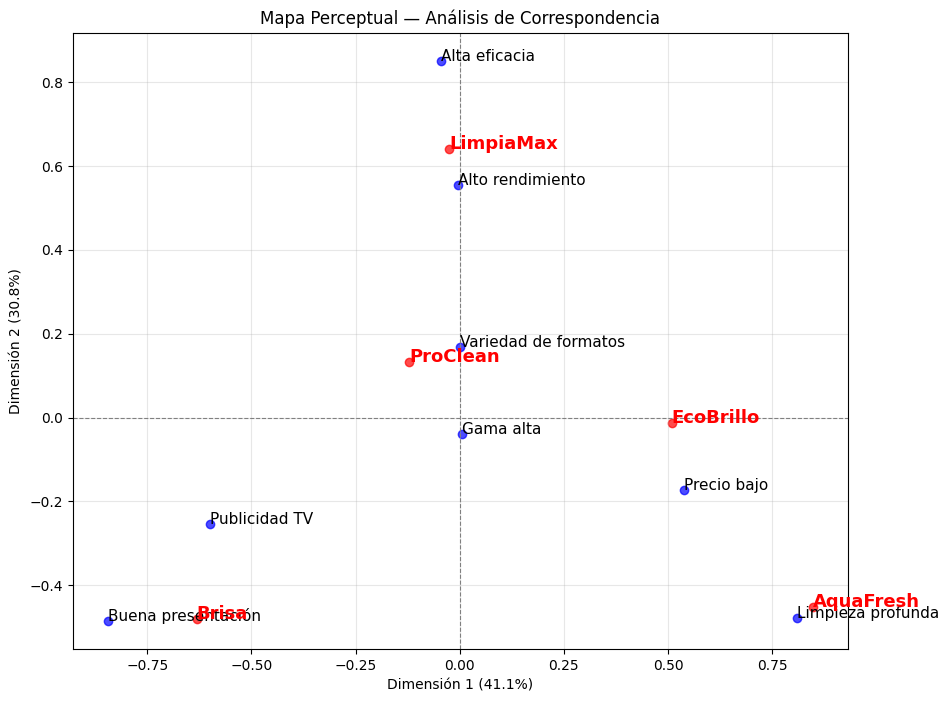

In [10]:
# ===========================================================
# MAPA 2D BÁSICO
# ===========================================================

dim1_pct = inercia[0]
dim2_pct = inercia[1]

plt.figure(figsize=(10, 8))

# Filas (atributos)
plt.scatter(filas[0], filas[1], color='blue', alpha=0.7)
for i, txt in enumerate(df.index):
    plt.text(filas.iloc[i, 0], filas.iloc[i, 1], txt, fontsize=11)

# Columnas (marcas)
plt.scatter(columnas[0], columnas[1], color='red', alpha=0.7)
for i, txt in enumerate(df.columns):
    plt.text(columnas.iloc[i, 0], columnas.iloc[i, 1], txt,
             fontsize=13, color='red', fontweight='bold')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.xlabel(f'Dimensión 1 ({dim1_pct:.1f}%)')
plt.ylabel(f'Dimensión 2 ({dim2_pct:.1f}%)')
plt.title('Mapa Perceptual — Análisis de Correspondencia')
plt.grid(True, alpha=0.3)

plt.show()

---
## 7. Mapa 2D con Elipses de Asociación

### Criterio de agrupación

Los grupos se definen observando la proximidad visual en el mapa perceptual básico y confirmando con los perfiles de fila/columna:

| Grupo | Elementos | Justificación |
|-------|-----------|---------------|
| **Grupo Brisa** | Publicidad TV, Buena presentación, Brisa | Brisa tiene los valores más altos en estos dos atributos (48.61% y 26.02%) |
| **Grupo LimpiaMax** | Alta eficacia, Alto rendimiento, LimpiaMax | LimpiaMax lidera en eficacia (52.63%) y segundo en rendimiento (20.87%) |
| **Grupo Eco/Aqua** | Precio bajo, Limpieza profunda, EcoBrillo, AquaFresh | EcoBrillo domina en precio (48.39%), AquaFresh en limpieza (54.84%) |
| **Grupo ProClean** | Variedad de formatos, ProClean | ProClean tiene mayor peso en variedad (12.57%) y gama alta (29.51%) |

Las elipses de covarianza (n_std=2) resumen la dispersión de cada grupo y sus centroides (marcados con ×) indican el centro de asociación.

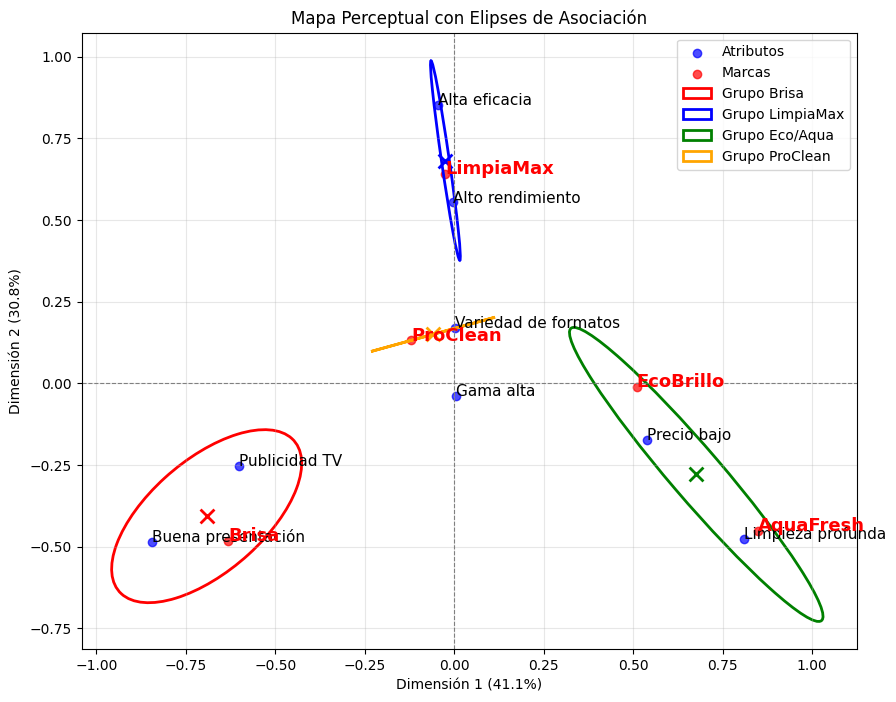

In [11]:
# ===========================================================
# MAPA 2D CON ELIPSES
# ===========================================================

plt.figure(figsize=(10, 8))

# Puntos filas (atributos)
plt.scatter(filas[0], filas[1], color='blue', label='Atributos', alpha=0.7)
for i, txt in enumerate(df.index):
    plt.text(filas.iloc[i, 0], filas.iloc[i, 1], txt, fontsize=11)

# Puntos columnas (marcas)
plt.scatter(columnas[0], columnas[1], color='red', label='Marcas', alpha=0.7)
for i, txt in enumerate(df.columns):
    plt.text(columnas.iloc[i, 0], columnas.iloc[i, 1], txt,
             fontsize=13, color='red', fontweight='bold')

# ==================================================
# ELIPSES AUTOMÁTICAS A PARTIR DE CENTROIDE Y COVARIANZA
# ==================================================

def agregar_elipse_covarianza(ax, puntos, color, etiqueta, n_std=2.0):
    puntos = np.asarray(puntos, dtype=float)
    if puntos.shape[0] < 2:
        return

    centroide = puntos.mean(axis=0)
    covarianza = np.cov(puntos, rowvar=False)
    if np.ndim(covarianza) == 0:
        covarianza = np.array([[covarianza, 0.0], [0.0, covarianza]])

    valores, vectores = np.linalg.eigh(covarianza)
    orden = valores.argsort()[::-1]
    valores = valores[orden]
    vectores = vectores[:, orden]
    valores = np.clip(valores, 1e-12, None)

    angulo = np.degrees(np.arctan2(vectores[1, 0], vectores[0, 0]))
    ancho = 2 * n_std * np.sqrt(valores[0])
    alto = 2 * n_std * np.sqrt(valores[1])

    elipse = Ellipse(
        xy=centroide,
        width=ancho,
        height=alto,
        angle=angulo,
        edgecolor=color,
        facecolor='none',
        linewidth=2,
        label=etiqueta
    )
    ax.add_patch(elipse)
    ax.scatter(centroide[0], centroide[1], color=color, marker='x', s=100, linewidths=2)

# Diccionario de coordenadas
coordenadas = {}
for etiqueta in filas.index:
    coordenadas[etiqueta] = filas.loc[etiqueta, [0, 1]].to_numpy()
for etiqueta in columnas.index:
    coordenadas[etiqueta] = columnas.loc[etiqueta, [0, 1]].to_numpy()

# Grupos justificados en la celda MD anterior
grupos = [
    ('Grupo Brisa', ['Publicidad TV', 'Buena presentación', 'Brisa'], 'red'),
    ('Grupo LimpiaMax', ['Alta eficacia', 'Alto rendimiento', 'LimpiaMax'], 'blue'),
    ('Grupo Eco/Aqua', ['Precio bajo', 'Limpieza profunda', 'EcoBrillo', 'AquaFresh'], 'green'),
    ('Grupo ProClean', ['Variedad de formatos', 'ProClean'], 'orange'),
]

ax = plt.gca()
for nombre_grupo, etiquetas, color in grupos:
    puntos = [coordenadas[etiqueta] for etiqueta in etiquetas]
    agregar_elipse_covarianza(ax, puntos, color=color, etiqueta=nombre_grupo)

# Líneas centrales
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.xlabel(f'Dimensión 1 ({dim1_pct:.1f}%)')
plt.ylabel(f'Dimensión 2 ({dim2_pct:.1f}%)')
plt.title('Mapa Perceptual con Elipses de Asociación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

---
## 8. Interpretaciones del Mapa

**Proximidad entre dos atributos:** Tienen perfiles parecidos, están fuertemente inter-correlacionados. Por ejemplo, "Alto rendimiento" y "Alta eficacia" tienen perfiles similares (ambos asociados a LimpiaMax).

**Proximidad entre dos marcas:** Tienen las mismas fortalezas y debilidades, se les han asociado los mismos atributos. Por ejemplo, `EcoBrillo` y `AquaFresh` comparten proximidad en el mapa.

**Proximidad entre atributos y marcas:** Existe una fuerte asociación entre el atributo y la marca. Por ejemplo, `Brisa` y "Buena presentación", o `AquaFresh` y "Limpieza profunda".

---
## 9. Conclusión General

El análisis evidencia que las marcas presentan posicionamientos perceptuales diferenciados:

| Marca | Posicionamiento |
|-------|----------------|
| **Brisa** | Publicidad TV y buena presentación |
| **LimpiaMax** | Alta eficacia y alto rendimiento |
| **EcoBrillo** | Precio económico |
| **ProClean** | Gama alta y variedad de formatos |
| **AquaFresh** | Alta capacidad de limpieza |

El análisis de correspondencia permitió identificar patrones claros de asociación entre marcas y atributos, facilitando el estudio del posicionamiento competitivo de los detergentes en la percepción de los consumidores.

La prueba chi-cuadrado confirmó la existencia de asociación estadísticamente significativa (p < 0.001), y las dos primeras dimensiones explican el **71.9%** de la inercia total, lo que indica una buena representación del espacio perceptual.

---
## 10. Implicaciones de Negocio

Basado en los resultados del análisis de correspondencia, se pueden formular las siguientes recomendaciones estratégicas:

### Brisa
- **Fortaleza:** Imagen y visibilidad (publicidad + presentación).
- **Oportunidad:** Reforzar asociación con atributos funcionales (eficacia, rendimiento) para no depender solo de imagen.

### LimpiaMax
- **Fortaleza:** Eficacia y rendimiento percibidos como superiores.
- **Oportunidad:** Mejorar presentación y visibilidad publicitaria para competir con Brisa.

### EcoBrillo
- **Fortaleza:** Posicionamiento claro como opción económica.
- **Riesgo:** Percepción limitada a precio; podría asociarse con menor calidad.
- **Oportunidad:** Comunicar eficacia para ampliar percepción más allá del precio.

### ProClean
- **Fortaleza:** Marca premium con mayor peso en el mercado (32.28% de masa).
- **Oportunidad:** Mantener diferenciación premium; explorar segmentos de mayor valor.

### AquaFresh
- **Fortaleza:** Asociación dominante con limpieza profunda.
- **Oportunidad:** Ampliar gama de atributos percibidos (presentación, variedad).

---
## 11. Extensión 3D Interactiva

Visualización en 3 dimensiones usando Plotly para explorar relaciones con mayor profundidad. La tercera dimensión captura variabilidad adicional no representada en el plano 2D.

In [12]:
# ===========================================================
# MODELO 3D
# ===========================================================

ca_3d = prince.CA(
    n_components=3,
    random_state=42
)
ca_3d = ca_3d.fit(df)

filas_3d = ca_3d.row_coordinates(df)
columnas_3d = ca_3d.column_coordinates(df)

inercia_3d = ca_3d.percentage_of_variance_

print("Inercia por dimensión (3D):")
for i, val in enumerate(inercia_3d):
    print(f"  Dim {i+1}: {val:.2f}%")
print(f"  Total: {sum(inercia_3d):.2f}%")

Inercia por dimensión (3D):
  Dim 1: 41.09%
  Dim 2: 30.83%
  Dim 3: 23.20%
  Total: 95.12%


In [13]:
# ===========================================================
# GRÁFICO 3D INTERACTIVO (Plotly)
# ===========================================================

d1 = inercia_3d[0]
d2 = inercia_3d[1]
d3 = inercia_3d[2]

fig = go.Figure()

# Atributos — filas
fig.add_trace(go.Scatter3d(
    x=filas_3d[0],
    y=filas_3d[1],
    z=filas_3d[2],
    mode='markers+text',
    text=filas_3d.index,
    textposition='top center',
    marker=dict(size=6, color='blue'),
    name='Atributos'
))

# Marcas — columnas
fig.add_trace(go.Scatter3d(
    x=columnas_3d[0],
    y=columnas_3d[1],
    z=columnas_3d[2],
    mode='markers+text',
    text=columnas_3d.index,
    textposition='top center',
    marker=dict(size=6, color='red'),
    name='Marcas'
))

fig.update_layout(
    title='Análisis de Correspondencia 3D Interactivo',
    scene=dict(
        xaxis_title=f'Dimensión 1 ({d1:.1f}%)',
        yaxis_title=f'Dimensión 2 ({d2:.1f}%)',
        zaxis_title=f'Dimensión 3 ({d3:.1f}%)'
    ),
    width=900,
    height=700
)

fig.show()